In [65]:
import pandas as pd
import numpy as np
from scipy import stats

# ============================================================
# 1. LOAD ALL MODEL RESULTS
# ============================================================
models = {}
for name in ['M0', 'M1', 'M2']:
    df = pd.read_csv(f'../output/results/{name}_results.csv')
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['country', 'date']).reset_index(drop=True)
    models[name] = df

# 

Saved: ../output/figures/grid_exporters.pdf
Saved: ../output/figures/grid_controls.pdf


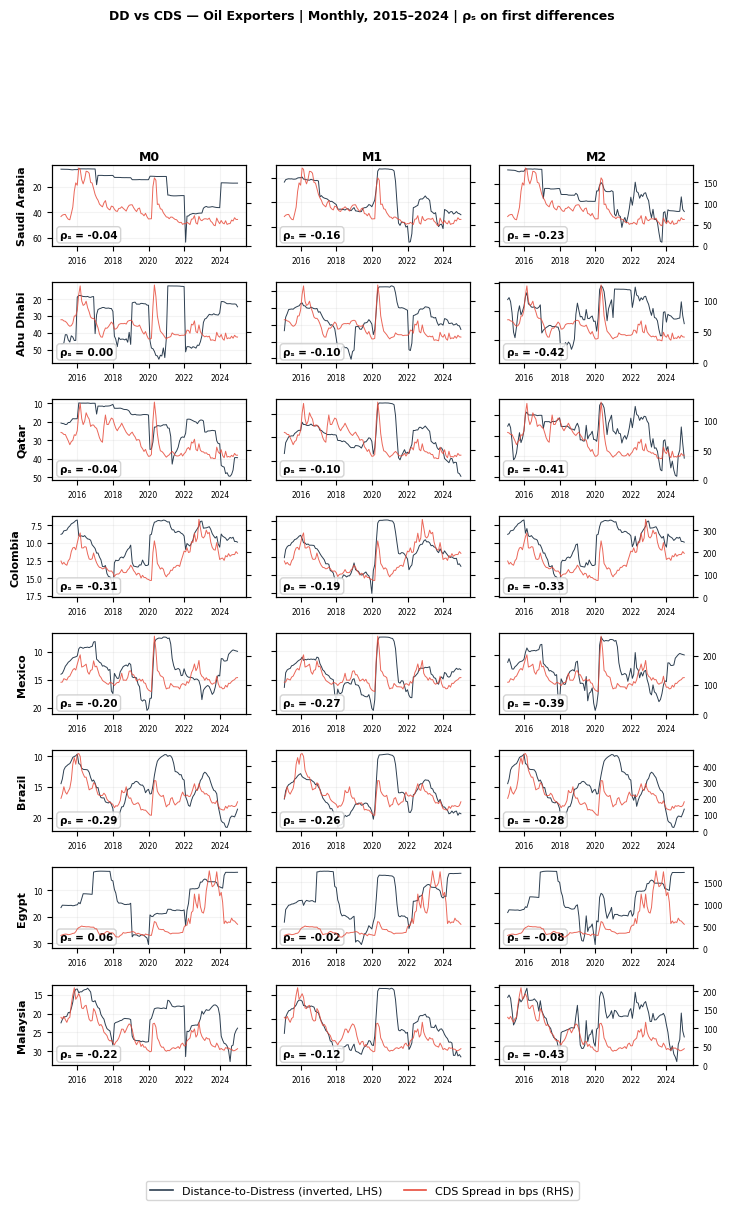

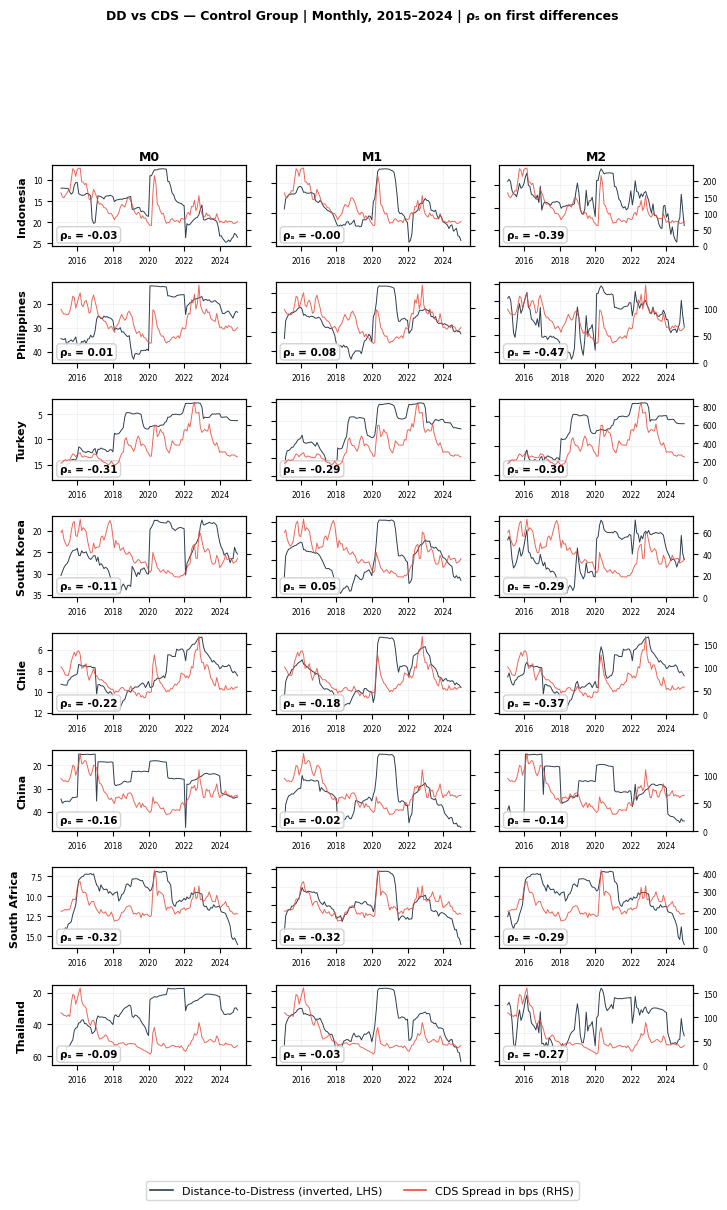

In [66]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

EXPORTERS = [
    'Saudi Arabia', 'Abu Dhabi', 'Qatar',
    'Colombia', 'Mexico', 'Brazil', 'Egypt', 'Malaysia',
]
CONTROLS = [
    'Indonesia', 'Philippines', 'Turkey', 'South Korea',
    'Chile', 'China', 'South Africa', 'Thailand',
]

A4_W, A4_H = 8.27, 11.69  # inches


def plot_group_grid(models_dict, countries, group_label, save_path=None):
    model_names = list(models_dict.keys())
    nrows = len(countries)
    ncols = len(model_names)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(A4_W, A4_H),
        gridspec_kw={'hspace': 0.45, 'wspace': 0.15}
    )

    for row, country in enumerate(countries):
        for col, mname in enumerate(model_names):
            ax1 = axes[row, col]
            ax2 = ax1.twinx()

            d = (models_dict[mname][models_dict[mname]['country'] == country]
                 .sort_values('date').copy())
            d['date'] = pd.to_datetime(d['date'])
            d = (d[d['date'] >= '2015-01-01']
                 .set_index('date')
                 .resample('ME').mean(numeric_only=True)
                 .reset_index())

            ax1.plot(d['date'], d['distance_to_distress'], color='#2C3E50', lw=0.7)
            ax2.plot(d['date'], d['cds_spread'], color='#E74C3C', lw=0.7, alpha=0.85)
            ax2.set_ylim(bottom=0)
            ax1.invert_yaxis()

            ax1.tick_params(labelsize=5.5)
            ax2.tick_params(labelsize=5.5)
            ax1.xaxis.set_major_locator(mdates.YearLocator(2))
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax1.grid(True, alpha=0.15)

            # Country label on left
            if col == 0:
                ax1.set_ylabel(country, fontsize=8, fontweight='bold', labelpad=4)
            else:
                ax1.set_yticklabels([])

            # Model label on top
            if row == 0:
                ax1.set_title(mname, fontsize=9, fontweight='bold', pad=4)

            # Hide right-axis ticks except last column
            if col < ncols - 1:
                ax2.set_yticklabels([])

            # Spearman rho on changes
            valid = d.dropna(subset=['distance_to_distress', 'cds_spread'])
            if len(valid) > 10:
                diffs = valid[['distance_to_distress', 'cds_spread']].diff().dropna()
                rho, _ = spearmanr(diffs['distance_to_distress'], diffs['cds_spread'])
                ax1.text(
                    0.04, 0.10, f'ρₛ = {rho:.2f}',
                    transform=ax1.transAxes,
                    fontsize=7.5, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor='#cccccc', alpha=0.85)
                )

    # Legend
    dd_line  = plt.Line2D([0], [0], color='#2C3E50', lw=1.2)
    cds_line = plt.Line2D([0], [0], color='#E74C3C', lw=1.2)
    fig.legend(
        [dd_line, cds_line],
        ['Distance-to-Distress (inverted, LHS)', 'CDS Spread in bps (RHS)'],
        loc='lower center', ncol=2, fontsize=8,
        bbox_to_anchor=(0.5, -0.01),
        frameon=True, edgecolor='#cccccc'
    )
    fig.text(
        0.5, 1.005,
        f'DD vs CDS — {group_label} | Monthly, 2015–2024 | ρₛ on first differences',
        ha='center', fontsize=9, fontweight='bold'
    )

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight', format='pdf')
        print(f'Saved: {save_path}')
    return fig


fig_exp = plot_group_grid(
    models, EXPORTERS, 'Oil Exporters',
    save_path='../output/figures/grid_exporters.pdf'
)
fig_ctrl = plot_group_grid(
    models, CONTROLS, 'Control Group',
    save_path='../output/figures/grid_controls.pdf'
)